# Chlorophyll Concentration

**Figure. Change in Chlorophyll from satellite.**  The map (top) shows the change in annual mean Chlorophyll-a concentration (mg/m³) in the vicinity of Palau during 1998–2024, derived from satellite remote sensing of ocean colour data. The grey line outlines the Palau EEZ. The line plot (bottom) shows the temporal variation in mean Chlorophyll-a concentration (mg/m³), averaged over the area shown in the map above. The black line indicates the long-term trend, which is not statistically significant (p > 0.05).

In [22]:
import sys
from pathlib import Path

# Make sure the project root (Codes/) is importable so we can `import config.*`
_root = Path.cwd()
if not (_root / "config").is_dir() and (_root.parent / "config").is_dir():
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.basemap import Basemap

from config.eez import getEEZ
from config.regions import resolve_region_settings
from config.spatial import subset_to_bbox

## Import Libraries

In [23]:
# -------------------------
# USER CONFIG (pick one)
# -------------------------
REGION = "PACIFIC"  # options: "PACIFIC", "NRU", "NIU"

# FOOTER TEXT
TEXT_LEFT = "Nauru Meteorological Service (NMS) 2026"
TEXT_RIGHT = "Copernicus"
PLOT_TITLE = "Satellite Chlorophyll Trends (1997–2021) — Pacific"

# Pull bbox + EEZ layer path from the shared config package
bbox, eez_zip_path = resolve_region_settings(REGION)

## Read NetCDF

In [24]:
# -------------------------
# Read NetCDF
# -------------------------
ds = Dataset("https://ocean-thredds01.spc.int/thredds/dodsC/POP/PCC/omi_health_chl_global_oceancolour_trend_97_21.nc", "r")
chl = ds.variables["trend"][:]
lat = ds.variables["latitude"][:]
lon = ds.variables["longitude"][:]

## Subsetting and Data Selection

In [25]:
# Replace fill values with masked values
fill_value = getattr(ds.variables["trend"], "_FillValue", None)
if fill_value is not None:
    chl = np.ma.masked_where(chl == fill_value, chl)

# Convert longitude from 0-360 to -180..180
lon = np.where(lon > 180, lon - 360, lon)

# Sort longitudes and reorder field accordingly
lon_sort = np.argsort(lon)
lon = lon[lon_sort]
chl = chl[:, lon_sort]

# Wrap lon to 0..360 for plotting/subsetting in Pacific-centered convention
lon_wrapped = np.where(lon < 0, lon + 360, lon)

# Sort wrapped longitudes and reorder field accordingly
wrap_sort = np.argsort(lon_wrapped)
lon_wrapped = lon_wrapped[wrap_sort]
chl = chl[:, wrap_sort]

# Subset to selected bbox (PACIFIC keeps original big domain)
lon2d, lat2d, chl_sub = subset_to_bbox(lat, lon_wrapped, chl, bbox)

# Levels / colormap
levels = np.arange(-3, 3, 0.5)
cmap = plt.get_cmap("jet")
norm = BoundaryNorm(levels, cmap.N)


## Plot

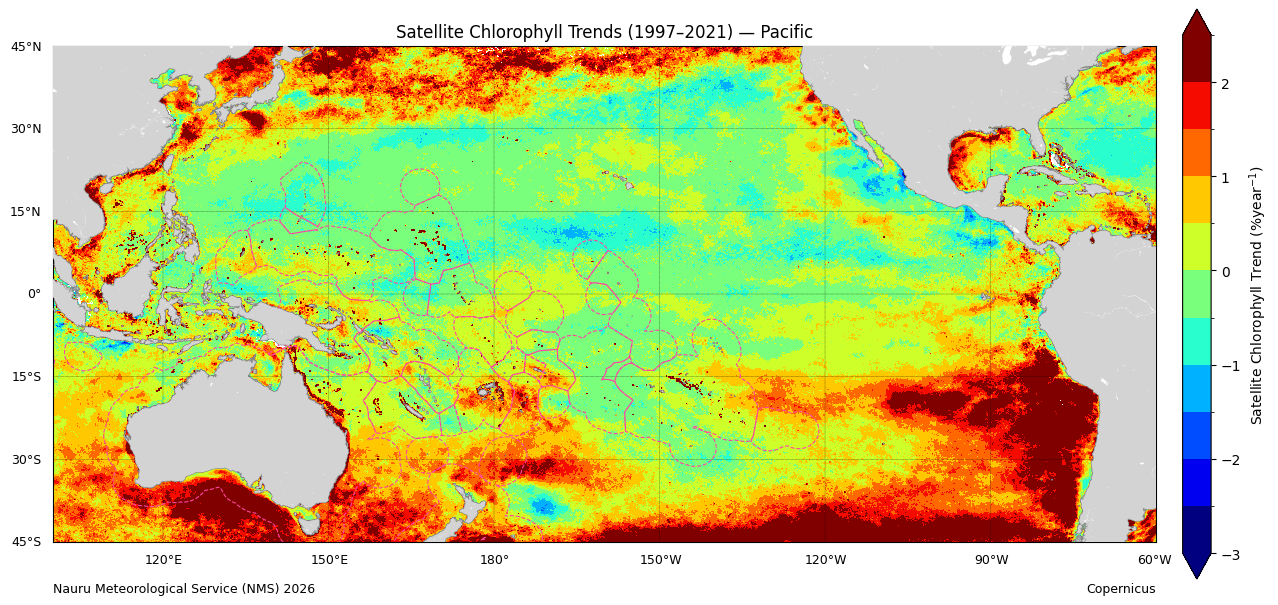

In [26]:

# -------------------------
# Plot
# -------------------------
fig = plt.figure(figsize=(14, 6))
ax = plt.gca()

m = Basemap(
    projection="cyl",
    llcrnrlon=bbox["west"],
    urcrnrlon=bbox["east"],
    llcrnrlat=bbox["south"],
    urcrnrlat=bbox["north"],
    resolution="h",
    ax=ax,
 )

cf = m.contourf(
    lon2d, lat2d, chl_sub,
    levels=levels, cmap=cmap, norm=norm,
    extend="both", latlon=True
)

m.drawcoastlines(color="grey", linewidth=0.8)
m.fillcontinents(color="lightgrey", lake_color="white", zorder=10)

# Gridlines: PACIFIC uses broader spacing; country zoom uses finer spacing
if REGION == "PACIFIC":
    par_step = 15
    mer_step = 30
else:
    par_step = 5
    mer_step = 5

par_start = np.floor(bbox["south"] / par_step) * par_step
par_end   = np.ceil(bbox["north"] / par_step) * par_step
mer_start = np.floor(bbox["west"] / mer_step) * mer_step
mer_end   = np.ceil(bbox["east"] / mer_step) * mer_step

m.drawparallels(np.arange(par_start, par_end + 0.1, par_step),
                labels=[1, 0, 0, 0], fontsize=9, linewidth=0.3, dashes=[1, 1])
m.drawmeridians(np.arange(mer_start, mer_end + 0.1, mer_step),
                labels=[0, 0, 0, 1], fontsize=9, linewidth=0.3, dashes=[1, 1])

cbar = plt.colorbar(cf, pad=0.02)
cbar.set_label("Satellite Chlorophyll Trend (%year$^{-1}$)")
plt.title(PLOT_TITLE)

# EEZ on top (last)
getEEZ(ax=ax, m=m, local_path=eez_zip_path, color="#FF46A2", linewidth=0.8, linestyle="--")

plt.tight_layout()

# Put footer relative to the axes (tracks bbox/plot size)
ax.text(0.0, -0.08, TEXT_LEFT,
        transform=ax.transAxes, ha="left", va="top",
        fontsize=9, color="black", clip_on=False)

ax.text(1.0, -0.08, TEXT_RIGHT,
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, color="black", clip_on=False)
plt.show()

ds.close()